# a phase portrait of gradient descent on a 1-hidden linear neuron

This notebook accompanies the post on the loss

$$
L(x,y)=\frac12(1-xy)^2.
$$

It builds the phase portraits and the small geometry figures used in the post.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

CONVERGES_NO_CROSSING = 0
CONVERGES_WITH_CROSSING = 1
SADDLE = 2
BLOW_UP = 3
UNRESOLVED = 4

CLASS_COLORS = {
    CONVERGES_NO_CROSSING: '#2ca02c',
    CONVERGES_WITH_CROSSING: '#ff7f0e',
    SADDLE: '#1f77b4',
    BLOW_UP: '#7b3294',
    UNRESOLVED: '#d0d0d0',
}

CLASS_LABELS = {
    CONVERGES_NO_CROSSING: r'to $xy=1$, no crossing',
    CONVERGES_WITH_CROSSING: r'to $xy=1$, with crossing',
    SADDLE: r'to saddle $(0,0)$',
    BLOW_UP: 'blow-up',
    UNRESOLVED: 'unresolved within budget',
}


def loss(x, y):
    return 0.5 * (1.0 - x * y) ** 2


def gd_step_xy(x, y, eta):
    n = x * y - 1.0
    return x - eta * n * y, y - eta * n * x


def xy_to_tn(x, y):
    return x * x - y * y, x * y - 1.0


def analyze_xy_trajectory(
    x0,
    y0,
    eta,
    *,
    steps=320,
    tol_n=1e-7,
    tol_origin=1e-6,
    settle_window=5,
    blowup_radius=1e8,
):
    x = float(x0)
    y = float(y0)
    _, n = xy_to_tn(x, y)

    crossings_n = 0
    n_hits = 1 if abs(n) < tol_n else 0
    origin_hits = 1 if (abs(x) < tol_origin and abs(y) < tol_origin and abs(n + 1.0) < tol_origin) else 0
    previous_n = n

    if origin_hits >= settle_window:
        return SADDLE
    if n_hits >= settle_window:
        return CONVERGES_NO_CROSSING

    for _ in range(steps):
        x, y = gd_step_xy(x, y, eta)
        _, n = xy_to_tn(x, y)

        if previous_n * n < 0.0:
            crossings_n += 1
        previous_n = n

        if (not np.isfinite(x)) or (not np.isfinite(y)) or abs(x) > blowup_radius or abs(y) > blowup_radius:
            return BLOW_UP

        n_hits = n_hits + 1 if abs(n) < tol_n else 0
        origin_hits = origin_hits + 1 if (abs(x) < tol_origin and abs(y) < tol_origin and abs(n + 1.0) < tol_origin) else 0

        if origin_hits >= settle_window:
            return SADDLE
        if n_hits >= settle_window:
            return CONVERGES_NO_CROSSING if crossings_n == 0 else CONVERGES_WITH_CROSSING

    return UNRESOLVED


def plot_landscape_and_critical_set(save_path=None):
    x = np.linspace(-2.4, 2.4, 220)
    y = np.linspace(-2.4, 2.4, 220)
    X, Y = np.meshgrid(x, y)
    Z = loss(X, Y)
    Z_clip = np.minimum(Z, 4.0)

    fig = plt.figure(figsize=(12.4, 5.2))

    ax = fig.add_subplot(1, 2, 1, projection='3d')
    ax.computed_zorder = False
    ax.plot_surface(X, Y, Z_clip, cmap='viridis', linewidth=0, antialiased=True, alpha=0.95, zorder=0)
    x_pos = np.linspace(0.42, 2.4, 500)
    x_neg = np.linspace(-2.4, -0.42, 500)
    z_curve = 0.16
    for lw, color in [(7.0, 'white'), (4.0, '#d62728')]:
        ax.plot(x_pos, 1 / x_pos, np.full_like(x_pos, z_curve), color=color, lw=lw, zorder=20)
        ax.plot(x_neg, 1 / x_neg, np.full_like(x_neg, z_curve), color=color, lw=lw, zorder=20)
    z_saddle = 0.90
    for lw, color in [(8.0, 'white'), (4.8, '#d62728')]:
        ax.plot([-0.22, 0.22], [-0.22, 0.22], [z_saddle, z_saddle], color=color, lw=lw, zorder=30)
        ax.plot([-0.22, 0.22], [0.22, -0.22], [z_saddle, z_saddle], color=color, lw=lw, zorder=30)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('')
    ax.set_zlim(0.0, 4.0)
    ax.set_title(r'$\min(L(x,y),4)$')
    ax.view_init(elev=62, azim=-135)

    ax = fig.add_subplot(1, 2, 2)
    contour = ax.contourf(X, Y, Z_clip, levels=24, cmap='viridis')
    ax.contour(X, Y, Z_clip, levels=[0.125, 0.5, 1.0, 2.0], colors='white', linewidths=0.7, alpha=0.8)
    ax.plot(x_pos, 1 / x_pos, color='#d62728', lw=2.8, label=r'$xy=1$')
    ax.plot(x_neg, 1 / x_neg, color='#d62728', lw=2.8)
    ax.scatter([0.0], [0.0], color='#d62728', marker='x', s=70, linewidths=2.6, label='saddle $(0,0)$')
    ax.set_aspect('equal')
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title('critical set in the $(x,y)$ plane')
    ax.legend(frameon=True, loc='upper right')
    fig.colorbar(contour, ax=ax, shrink=0.85, pad=0.02)

    fig.tight_layout(rect=[0.03, 0.0, 1.0, 1.0])
    if save_path is not None:
        fig.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()


def build_phase_map(eta, *, grid=np.linspace(-3.0, 3.0, 101), steps=320):
    labels = np.empty((len(grid), len(grid)), dtype=int)
    counts = {label: 0 for label in CLASS_COLORS}
    for iy, y0 in enumerate(grid):
        for ix, x0 in enumerate(grid):
            label = analyze_xy_trajectory(x0, y0, eta, steps=steps)
            labels[iy, ix] = label
            counts[label] += 1
    return labels, counts


def plot_phase_gallery(etas, *, grid=np.linspace(-3.0, 3.0, 101), steps=320, save_path=None):
    cmap = ListedColormap([CLASS_COLORS[k] for k in range(5)])
    fig, axes = plt.subplots(2, 3, figsize=(12.6, 7.8), sharex=True, sharey=True)
    all_counts = {}

    for ax, eta in zip(axes.flat, etas):
        labels, counts = build_phase_map(float(eta), grid=grid, steps=steps)
        all_counts[float(eta)] = counts
        ax.imshow(
            labels,
            origin='lower',
            extent=[grid[0], grid[-1], grid[0], grid[-1]],
            interpolation='nearest',
            cmap=cmap,
            vmin=-0.5,
            vmax=4.5,
            aspect='equal',
        )
        ax.set_title(rf'$\eta={eta:.2f}$')
        ax.set_xlabel(r'$x$')
        ax.set_ylabel(r'$y$')

    handles = [Patch(facecolor=CLASS_COLORS[k], edgecolor='black', label=CLASS_LABELS[k]) for k in range(5)]
    fig.subplots_adjust(bottom=0.16, wspace=0.16, hspace=0.25)
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 0.03), ncol=3, frameon=True)
    fig.suptitle(r'Observed GD phase portraits on a $101\times 101$ equally spaced grid in $(x,y) \in [-3,3]^2$', fontsize=16)
    if save_path is not None:
        fig.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()
    return all_counts



def plot_coordinate_geometry(save_path=None):
    fig, ax = plt.subplots(figsize=(5.4, 4.3))

    x_pos = np.linspace(0.55, 2.6, 500)
    ax.plot(x_pos, 1.0 / x_pos, color='#222222', lw=3.0)

    x0 = 1.25
    y0 = 1.0 / x0
    normal = np.array([y0, x0], dtype=float)
    normal = normal / np.linalg.norm(normal)
    tangent = np.array([2.0 * x0, -2.0 * y0], dtype=float)
    tangent = tangent / np.linalg.norm(tangent)

    ax.scatter([x0], [y0], s=55, color='#111111', zorder=5)
    ax.arrow(x0, y0, 0.58 * normal[0], 0.58 * normal[1], head_width=0.05, head_length=0.08,
             length_includes_head=True, color='#4c78a8', lw=2.2, zorder=6)
    ax.arrow(x0, y0, 0.70 * tangent[0], 0.70 * tangent[1], head_width=0.05, head_length=0.08,
             length_includes_head=True, color='#f58518', lw=2.2, zorder=6)

    ax.text(1.56, 1.28, r'$\nabla n=(y,x)$', color='#4c78a8', fontsize=12)
    ax.text(1.75, 0.36, r'$\nabla t=(2x,-2y)$', color='#f58518', fontsize=12)
    ax.text(2.05, 0.62, r'$xy=1$', color='#222222', fontsize=13)

    ax.set_xlim(0.5, 2.65)
    ax.set_ylim(0.25, 1.75)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(r'normal and tangent directions near $xy=1$')
    ax.grid(alpha=0.12)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()


def stable_t_bound(eta):
    eta = float(eta)
    if eta >= 1.0:
        return 0.0
    return float(((2.0 / eta) ** 2 - 4.0) ** 0.5)


def plot_stable_minimizer_arcs(etas=(0.35, 0.55, 0.75, 0.95), save_path=None):
    fig, axes = plt.subplots(1, len(etas), figsize=(12.8, 3.5), sharex=True, sharey=True)
    if len(etas) == 1:
        axes = [axes]

    x_pos = np.linspace(0.34, 3.0, 900)
    x_neg = np.linspace(-3.0, -0.34, 900)

    for ax, eta in zip(axes, etas):
        for x in (x_pos, x_neg):
            y = 1.0 / x
            t = x * x - y * y
            stable = np.abs(t) < stable_t_bound(eta)
            ax.plot(x, y, color='#d0d0d0', lw=2.4, solid_capstyle='round')
            ax.plot(x[stable], y[stable], color='#4c78a8', lw=4.0, solid_capstyle='round')

        ax.scatter([1, -1], [1, -1], s=32, color='#111111', zorder=5)
        ax.set_title(rf'$\eta={eta:.2f}$')
        ax.set_aspect('equal')
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_xlabel(r'$x$')
        ax.grid(alpha=0.12)
        if ax is axes[0]:
            ax.set_ylabel(r'$y$')

    handles = [
        Patch(facecolor='#4c78a8', edgecolor='#4c78a8', label=r'stable minimizers: $\eta\,s(t)<2$'),
        Patch(facecolor='#d0d0d0', edgecolor='#d0d0d0', label=r'other points on $xy=1$'),
    ]
    fig.legend(handles=handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.08))
    fig.suptitle(r'the stable part of $xy=1$ shrinks as $\eta$ increases', y=1.18, fontsize=15)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()


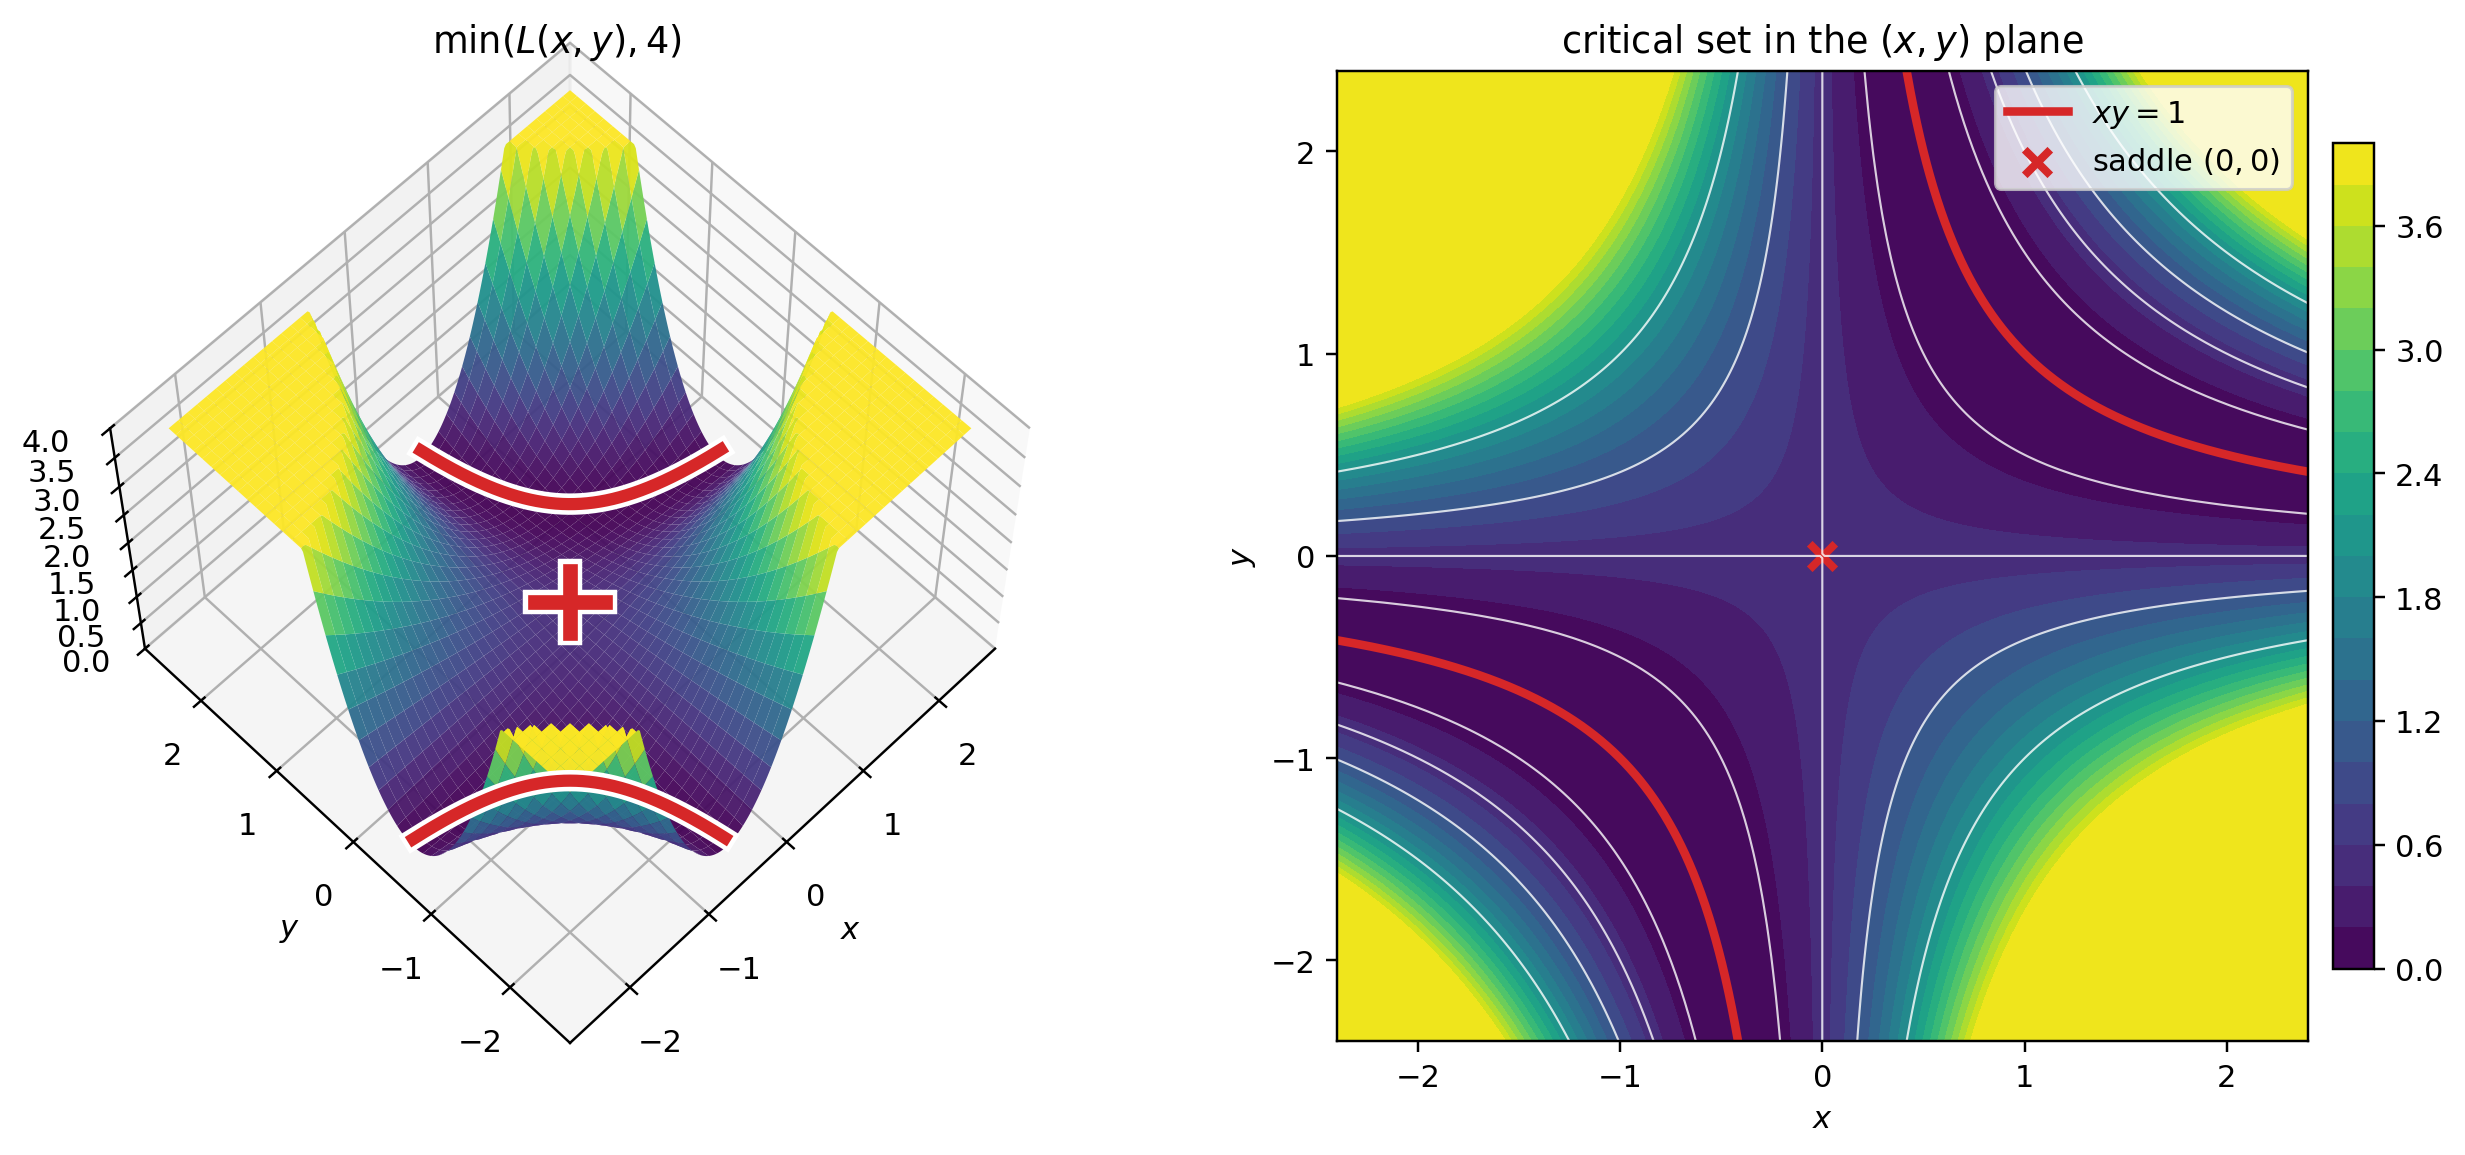

In [2]:
plot_landscape_and_critical_set()


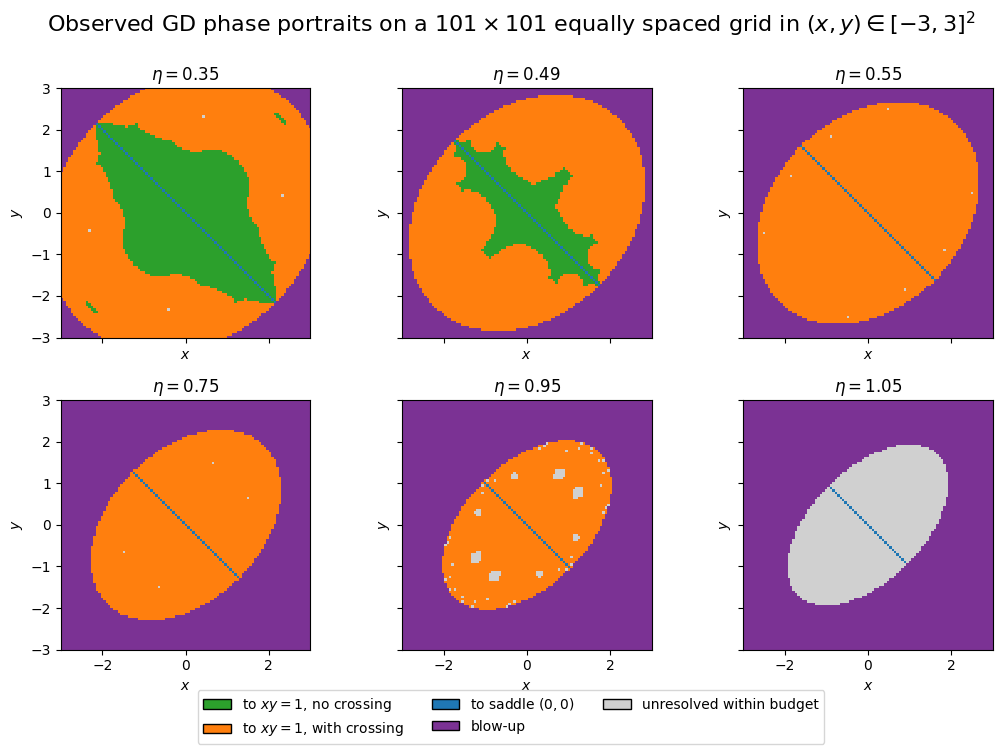

eta=0.35
  to $xy=1$, no crossing: 31.8%
  to $xy=1$, with crossing: 56.1%
  to saddle $(0,0)$: 0.7%
  blow-up: 11.4%
  unresolved within budget: 0.0%
eta=0.49
  to $xy=1$, no crossing: 13.7%
  to $xy=1$, with crossing: 53.4%
  to saddle $(0,0)$: 0.6%
  blow-up: 32.3%
  unresolved within budget: 0.0%
eta=0.55
  to $xy=1$, no crossing: 0.0%
  to $xy=1$, with crossing: 59.0%
  to saddle $(0,0)$: 0.5%
  blow-up: 40.4%
  unresolved within budget: 0.1%
eta=0.75
  to $xy=1$, no crossing: 0.0%
  to $xy=1$, with crossing: 41.7%
  to saddle $(0,0)$: 0.4%
  blow-up: 57.8%
  unresolved within budget: 0.0%
eta=0.95
  to $xy=1$, no crossing: 0.0%
  to $xy=1$, with crossing: 30.1%
  to saddle $(0,0)$: 0.3%
  blow-up: 68.3%
  unresolved within budget: 1.3%
eta=1.05
  to $xy=1$, no crossing: 0.0%
  to $xy=1$, with crossing: 0.0%
  to saddle $(0,0)$: 0.3%
  blow-up: 72.2%
  unresolved within budget: 27.4%


In [3]:
PHASE_ETAS = [0.35, 0.49, 0.55, 0.75, 0.95, 1.05]
counts = plot_phase_gallery(PHASE_ETAS)

for eta in PHASE_ETAS:
    total = sum(counts[float(eta)].values())
    print(f'eta={eta:.2f}')
    for label in [CONVERGES_NO_CROSSING, CONVERGES_WITH_CROSSING, SADDLE, BLOW_UP, UNRESOLVED]:
        frac = 100 * counts[float(eta)][label] / total
        print(f'  {CLASS_LABELS[label]}: {frac:.1f}%')


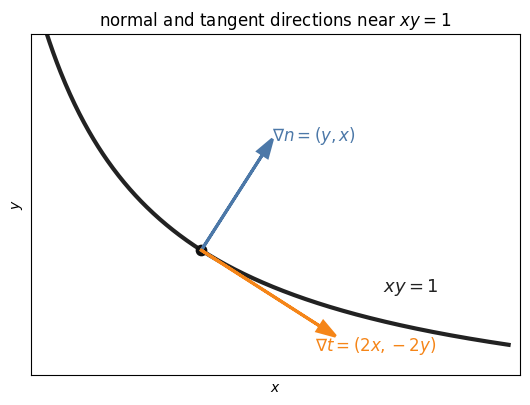

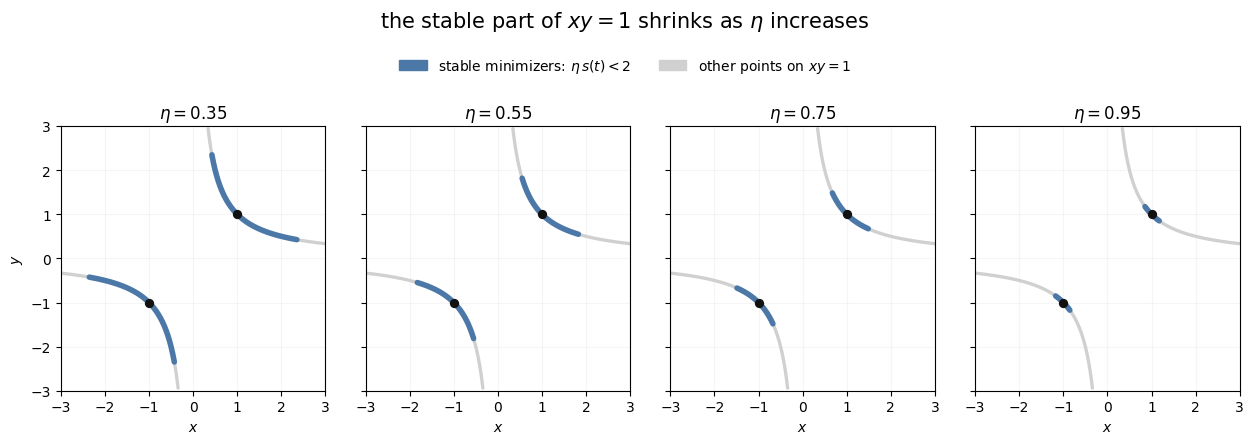

In [4]:
plot_coordinate_geometry()
plot_stable_minimizer_arcs()
